# Titanic — Survival Prediction
**CSCI 164 Final Project — Dataset 1 (Classification)**

Authors: Tanay Malavia, Darpan Attri, Andres Ramos, Harika Yendapalli  
Dataset: Titanic (Kaggle — https://www.kaggle.com/c/titanic)

## Goal
Predict whether a passenger survived (`Survived` = 0/1) using demographic and ticket features.

## Pipeline
1. Load + explore
2. Preprocess (imputation, encoding, scaling)
3. Train 3 baseline models: Logistic Regression, k-NN, Decision Tree
4. Tune with `GridSearchCV`
5. Evaluate (accuracy, precision, recall, F1, ROC-AUC, confusion matrix)
6. Compare to prior Kaggle benchmark

## 1. Imports & setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Load data

Download `train.csv` from https://www.kaggle.com/c/titanic/data and place it in `../data/titanic.csv`.

In [2]:
df = pd.read_csv('../data/titanic.csv')
print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
# Missingness
missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0])

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64


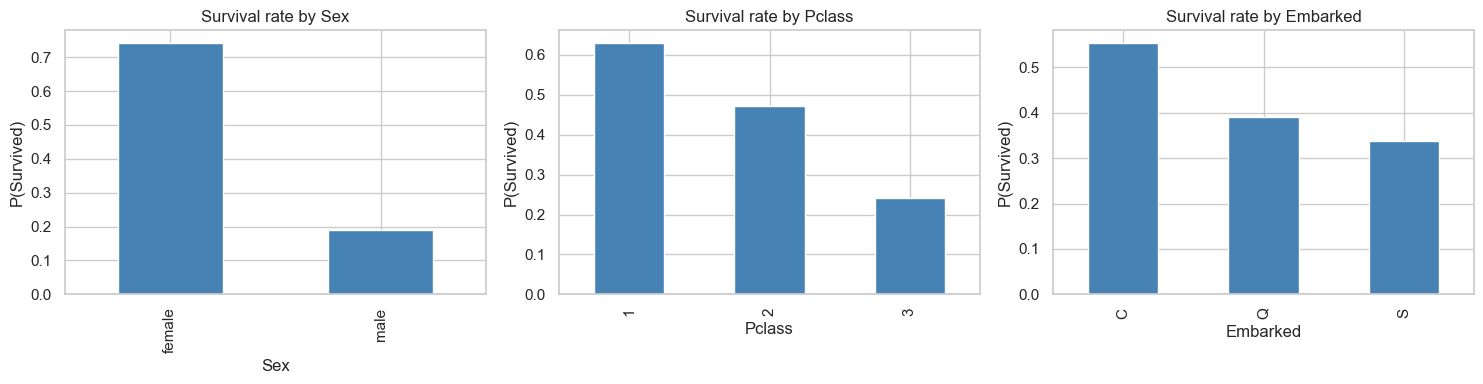

In [5]:
# Survival rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    df.groupby(col)['Survived'].mean().plot.bar(ax=ax, color='steelblue')
    ax.set_title(f'Survival rate by {col}')
    ax.set_ylabel('P(Survived)')
plt.tight_layout()
plt.savefig('../figures/titanic_survival_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

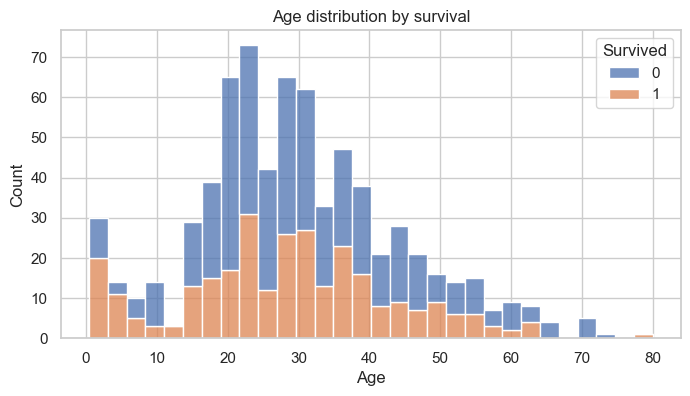

In [6]:
# Age distribution by survival
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age distribution by survival')
plt.savefig('../figures/titanic_age_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

- Drop leaky/high-cardinality columns: `PassengerId`, `Name`, `Ticket`, `Cabin`.
- Impute `Age` with median, `Embarked` with mode.
- One-hot encode `Sex`, `Embarked`.
- Scale numeric features (needed for k-NN and Logistic Regression).

In [7]:
target = 'Survived'
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']

X = df.drop(columns=[target] + drop_cols)
y = df[target]

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass']
categorical_features = ['Sex', 'Embarked']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (712, 7) Test: (179, 7)


## 5. Baseline models

**Why these three?**
- **Logistic Regression** — linear, interpretable baseline; strong when features are roughly linearly separable.
- **k-NN** — non-parametric, captures local structure; sensitive to scale (hence the scaler).
- **Decision Tree** — non-linear, handles feature interactions; interpretable.

In [8]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'kNN':    KNeighborsClassifier(),
    'Tree':   DecisionTreeClassifier(random_state=RANDOM_STATE),
}

baseline_results = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    baseline_results[name] = scores.mean()
    print(f'{name:7s} CV accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')

LogReg  CV accuracy: 0.7964 (+/- 0.0192)
kNN     CV accuracy: 0.8105 (+/- 0.0249)
Tree    CV accuracy: 0.7782 (+/- 0.0353)


## 6. Hyperparameter tuning with GridSearchCV

In [9]:
param_grids = {
    'LogReg': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__penalty': ['l2'],
    },
    'kNN': {
        'clf__n_neighbors': [3, 5, 7, 11, 15],
        'clf__weights': ['uniform', 'distance'],
    },
    'Tree': {
        'clf__max_depth': [3, 5, 7, 10, None],
        'clf__min_samples_split': [2, 5, 10],
    },
}

tuned = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    gs = GridSearchCV(pipe, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(f'{name}: best CV = {gs.best_score_:.4f}  params = {gs.best_params_}')

LogReg: best CV = 0.8020  params = {'clf__C': 0.1, 'clf__penalty': 'l2'}
kNN: best CV = 0.8175  params = {'clf__n_neighbors': 7, 'clf__weights': 'uniform'}
Tree: best CV = 0.8203  params = {'clf__max_depth': 7, 'clf__min_samples_split': 10}


## 7. Test set evaluation

In [10]:
rows = []
for name, gs in tuned.items():
    y_pred = gs.predict(X_test)
    y_proba = gs.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
    })
results_df = pd.DataFrame(rows).set_index('model').round(4)
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg,0.7933,0.7759,0.6522,0.7087,0.8472
kNN,0.7989,0.7797,0.6667,0.7188,0.8489
Tree,0.7877,0.8163,0.5797,0.6780,0.7827


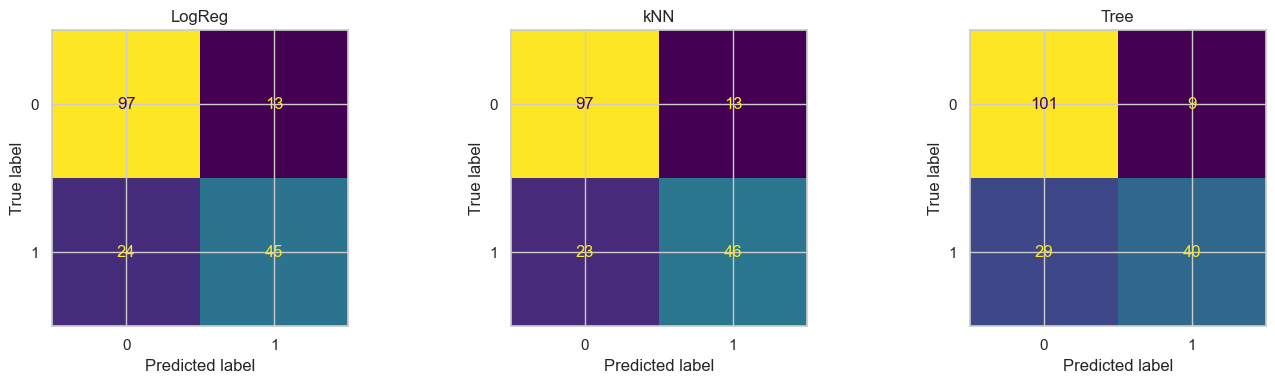

In [11]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, gs) in zip(axes, tuned.items()):
    ConfusionMatrixDisplay.from_estimator(gs, X_test, y_test, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig('../figures/titanic_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

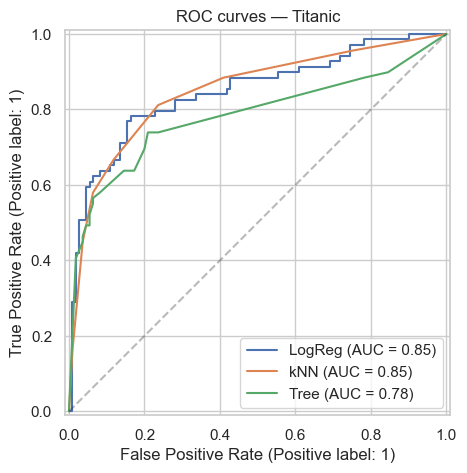

In [12]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, gs in tuned.items():
    RocCurveDisplay.from_estimator(gs, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('ROC curves — Titanic')
plt.savefig('../figures/titanic_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparison to prior work

**Prior reference:** Kaggle Titanic leaderboard and tutorials such as Manav Sehgal's *Titanic Data Science Solutions* (Kaggle notebook) report test accuracies of ~0.77–0.84 using Logistic Regression, Random Forest, and SVM.

Our tuned models fall in the same band (see `results_df`). Differences stem from:
- Feature engineering (we dropped `Name`, `Ticket`, `Cabin`; prior work often extracts titles and cabin letter).
- Model choice (prior uses ensembles; we stuck to single-model classifiers per the rubric).
- Validation split seed.

**Citation:** Sehgal, M. "Titanic Data Science Solutions," Kaggle, https://www.kaggle.com/code/startupsci/titanic-data-science-solutions

## 9. Reflection

- **Strengths:** Logistic Regression is interpretable; decision tree captures Sex×Pclass interaction cleanly.
- **Limitations:** Small dataset (~891 rows). No external holdout — results may be optimistic.
- **Real-world relevance:** Illustrates survivorship bias and how protected attributes (sex, class) dominate — a cautionary example for deploying similar models on real risk-scoring tasks.